In [3]:
!pip install -q -U ultralytics gradio kagglehub pyyaml

print("✅ Required packages installed.")

✅ Required packages installed.


In [4]:
import os
import glob
import json
import shutil
from pathlib import Path
from collections import Counter

import cv2
import gradio as gr
import kagglehub
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image
from ultralytics import YOLO
from IPython.display import display

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU is not enabled. Training will be much slower on CPU.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [5]:
KAGGLE_DATASET = "hussainnasirkhan/fire-and-smoke-detection-dataset"

dataset_root = Path(kagglehub.dataset_download(KAGGLE_DATASET))

print("✅ Dataset downloaded.")
print("Dataset root:", dataset_root)

# Show the first few files/folders to understand the package.
items = list(dataset_root.rglob("*"))
for p in items[:40]:
    print(p.relative_to(dataset_root))

Using Colab cache for faster access to the 'fire-and-smoke-detection-dataset' dataset.
✅ Dataset downloaded.
Dataset root: /kaggle/input/fire-and-smoke-detection-dataset
data.yaml
Fire-and-Smoke-Detection-Dataset
Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset
Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset
Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/valid
Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/test
Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/train
Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/valid/labels
Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/valid/labels.cache
Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/valid/images
Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/test/labels
Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detecti

In [6]:
yaml_candidates = list(dataset_root.rglob("data.yaml")) + list(dataset_root.rglob("*.yaml"))

# Remove duplicates while preserving order
seen = set()
yaml_candidates = [p for p in yaml_candidates if not (str(p) in seen or seen.add(str(p)))]

print("YAML candidates:")
for p in yaml_candidates[:20]:
    print(" -", p)

if not yaml_candidates:
    raise FileNotFoundError(
        "No YAML file was found in this dataset. "
        "Use the manual upload option later in this notebook or create data.yaml."
    )

# Prefer a file literally named data.yaml
data_yaml = next((p for p in yaml_candidates if p.name == "data.yaml"), yaml_candidates[0])

print("\n✅ Using:", data_yaml)

with open(data_yaml, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

print("\nDataset YAML:")
print(json.dumps(data_cfg, indent=2, default=str))

YAML candidates:
 - /kaggle/input/fire-and-smoke-detection-dataset/data.yaml

✅ Using: /kaggle/input/fire-and-smoke-detection-dataset/data.yaml

Dataset YAML:
{
  "train": "/kaggle/input/fire-and-smoke-detection-dataset/Fire-and-Smoke-Detection-Dataset/dataset/train/images",
  "val": "/kaggle/input/fire-and-smoke-detection-dataset/Fire-and-Smoke-Detection-Dataset/dataset/valid/images",
  "test": "/kaggle/input/fire-and-smoke-detection-dataset/Fire-and-Smoke-Detection-Dataset/dataset/test/images",
  "nc": 2,
  "names": [
    "fire",
    "smoke"
  ]
}


In [7]:
names = data_cfg.get("names", {})

if isinstance(names, dict):
    class_names = [names[k] for k in sorted(names, key=lambda x: int(x) if str(x).isdigit() else str(x))]
else:
    class_names = list(names)

print("Classes found:", class_names)

lower_names = [str(x).lower() for x in class_names]
if not any("fire" in x for x in lower_names):
    print("⚠️ No class containing 'fire' was found.")
if not any("smoke" in x for x in lower_names):
    print("⚠️ No class containing 'smoke' was found.")

print("\nThe risk logic later uses class-name keywords such as 'fire', 'flame', and 'smoke'.")

Classes found: ['fire', 'smoke']

The risk logic later uses class-name keywords such as 'fire', 'flame', and 'smoke'.


In [8]:
import os
from pathlib import Path
import yaml
from ultralytics.data.utils import check_det_dataset

# Find original data.yaml
yaml_candidates = list(dataset_root.rglob("data.yaml"))

if not yaml_candidates:
    raise FileNotFoundError("data.yaml not found")

original_yaml = yaml_candidates[0]

with open(original_yaml, "r") as f:
    original_cfg = yaml.safe_load(f)

print("Original YAML:", original_yaml)
print(original_cfg)


# ------------------------------------------------
# Find correct image folders
# ------------------------------------------------

def find_images(root, split_names):
    for images_dir in Path(root).rglob("images"):
        if images_dir.parent.name.lower() in split_names:
            labels_dir = images_dir.parent / "labels"

            if labels_dir.exists():
                return images_dir

    return None


train_images = find_images(
    dataset_root,
    {"train", "training"}
)

val_images = find_images(
    dataset_root,
    {"valid", "val", "validation"}
)

test_images = find_images(
    dataset_root,
    {"test", "testing"}
)

print("\nCorrect folders:")
print("Train:", train_images)
print("Val:", val_images)
print("Test:", test_images)


if train_images is None:
    raise FileNotFoundError("train/images not found")

if val_images is None:
    raise FileNotFoundError("valid/val images not found")


# ------------------------------------------------
# Find common dataset directory
# ------------------------------------------------

paths = [
    str(train_images),
    str(val_images)
]

if test_images:
    paths.append(str(test_images))

dataset_base = Path(os.path.commonpath(paths))

print("\nDataset Base:")
print(dataset_base)


# ------------------------------------------------
# Create corrected YAML
# ------------------------------------------------

fixed_cfg = dict(original_cfg)

fixed_cfg["path"] = str(dataset_base)

fixed_cfg["train"] = str(
    train_images.relative_to(dataset_base)
)

fixed_cfg["val"] = str(
    val_images.relative_to(dataset_base)
)

if test_images:
    fixed_cfg["test"] = str(
        test_images.relative_to(dataset_base)
    )
else:
    fixed_cfg.pop("test", None)


fixed_yaml = "/content/fire_smoke_data_fixed.yaml"

with open(fixed_yaml, "w") as f:
    yaml.safe_dump(
        fixed_cfg,
        f,
        sort_keys=False
    )

data_yaml = fixed_yaml
data_cfg = fixed_cfg

print("\n✅ Corrected data.yaml created")
print(data_yaml)

print("\nCorrected YAML:")
print(
    yaml.safe_dump(
        fixed_cfg,
        sort_keys=False
    )
)


# ------------------------------------------------
# Validate dataset BEFORE training
# ------------------------------------------------

checked = check_det_dataset(data_yaml)

print("\n✅ DATASET VALIDATION PASSED")
print("Train:", checked.get("train"))
print("Val:", checked.get("val"))
print("Test:", checked.get("test"))

Original YAML: /kaggle/input/fire-and-smoke-detection-dataset/data.yaml
{'train': '/kaggle/input/fire-and-smoke-detection-dataset/Fire-and-Smoke-Detection-Dataset/dataset/train/images', 'val': '/kaggle/input/fire-and-smoke-detection-dataset/Fire-and-Smoke-Detection-Dataset/dataset/valid/images', 'test': '/kaggle/input/fire-and-smoke-detection-dataset/Fire-and-Smoke-Detection-Dataset/dataset/test/images', 'nc': 2, 'names': ['fire', 'smoke']}

Correct folders:
Train: /kaggle/input/fire-and-smoke-detection-dataset/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/train/images
Val: /kaggle/input/fire-and-smoke-detection-dataset/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/valid/images
Test: /kaggle/input/fire-and-smoke-detection-dataset/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/test/images

Dataset Base:
/kaggle/input/fire-and-smoke-detection-dataset/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detectio

In [9]:
BASE_MODEL = "yolo11n.pt"
EPOCHS = 20
IMAGE_SIZE = 640

training_model = YOLO(BASE_MODEL)

train_results = training_model.train(
    data=str(data_yaml),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=-1,            # automatic batch sizing where supported
    device=DEVICE,
    project="/content/fire_smoke_project",
    name="yolo_fire_smoke",
    patience=10,
    plots=True,
)

print("✅ Training finished.")

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fire_smoke_data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_fire_smoke, nbs=64, 

In [10]:
best_candidates = list(Path("/content/fire_smoke_project").rglob("best.pt"))

if not best_candidates:
    raise FileNotFoundError("best.pt was not found. Check the training output above.")

BEST_MODEL = best_candidates[-1]

print("✅ Best model:", BEST_MODEL)

✅ Best model: /content/fire_smoke_project/yolo_fire_smoke/weights/best.pt


In [11]:
fire_model = YOLO(str(BEST_MODEL))

metrics = fire_model.val(
    data=str(data_yaml),
    imgsz=IMAGE_SIZE,
    device=DEVICE,
    plots=True,
)

print("✅ Validation complete.")

try:
    print(f"mAP50:      {metrics.box.map50:.4f}")
    print(f"mAP50-95:   {metrics.box.map:.4f}")
    print(f"Precision:  {metrics.box.mp:.4f}")
    print(f"Recall:     {metrics.box.mr:.4f}")
except Exception:
    print("Metrics object:", metrics)


Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.3 ms, read: 283.9±161.6 MB/s, size: 114.9 KB)
val: Scanning /kaggle/input/fire-and-smoke-detection-dataset/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/valid/labels... 1277 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1277/1277 507.3it/s 2.5s
WARNING ⚠️ val: Cache directory /kaggle/input/fire-and-smoke-detection-dataset/Fire-and-Smoke-Detection-Dataset/Fire-and-Smoke-Detection-Dataset/dataset/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 80/80 5.0it/s 16.1s
                   all       1277       3931      0.528      0.482      0.494      0.197
                  fire        944       2121      0.537      0.583      0.575      0.227
                 

Training run directory: /content/fire_smoke_project/yolo_fire_smoke

 results.png


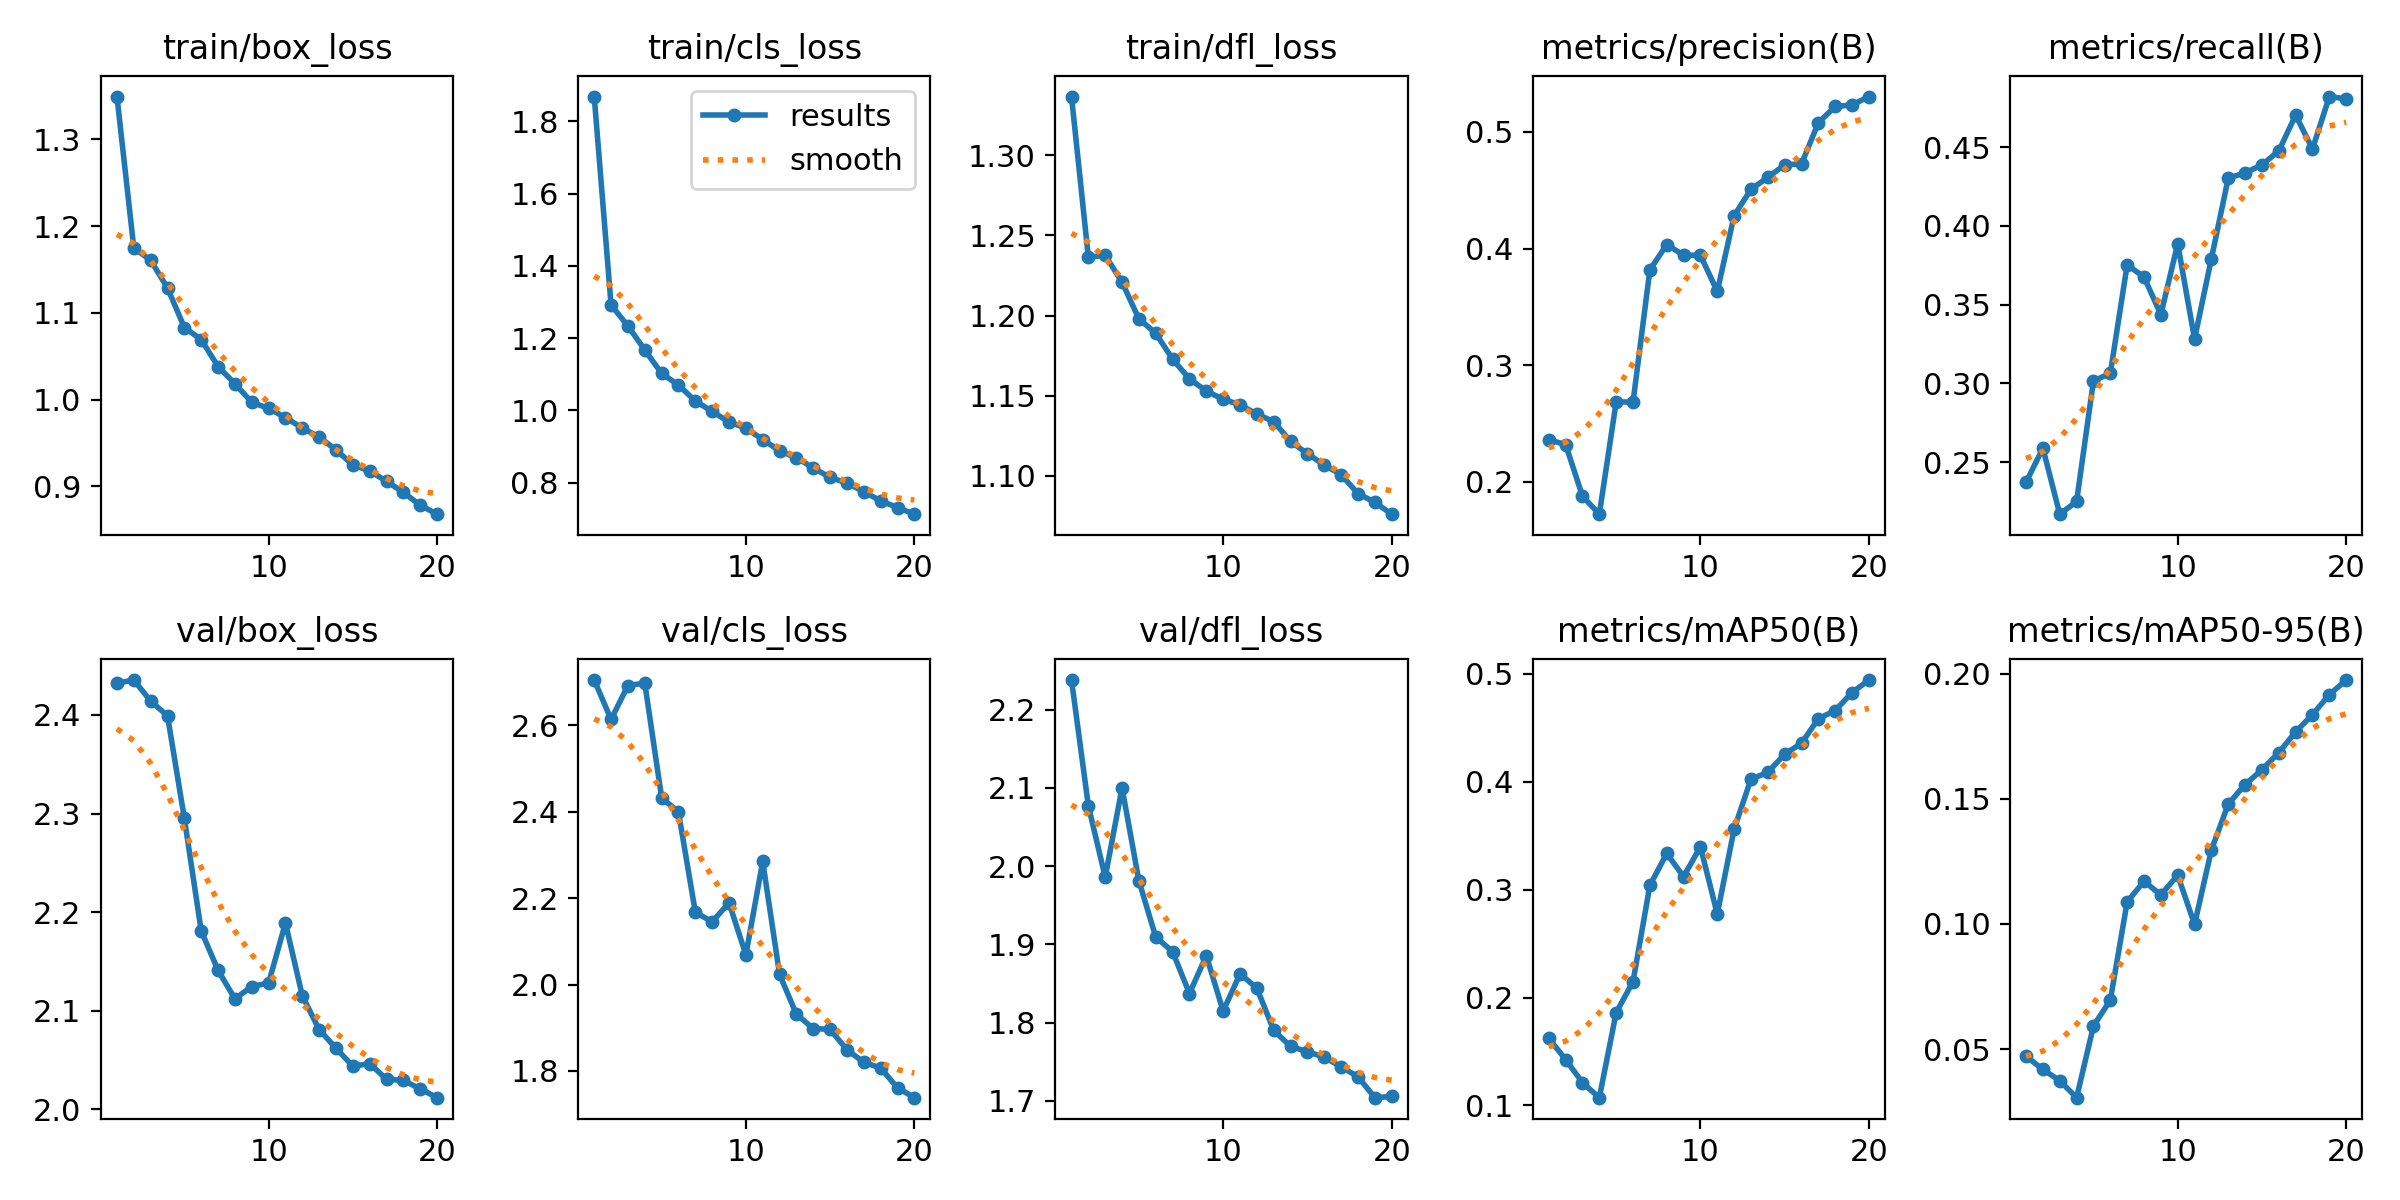


 confusion_matrix.png


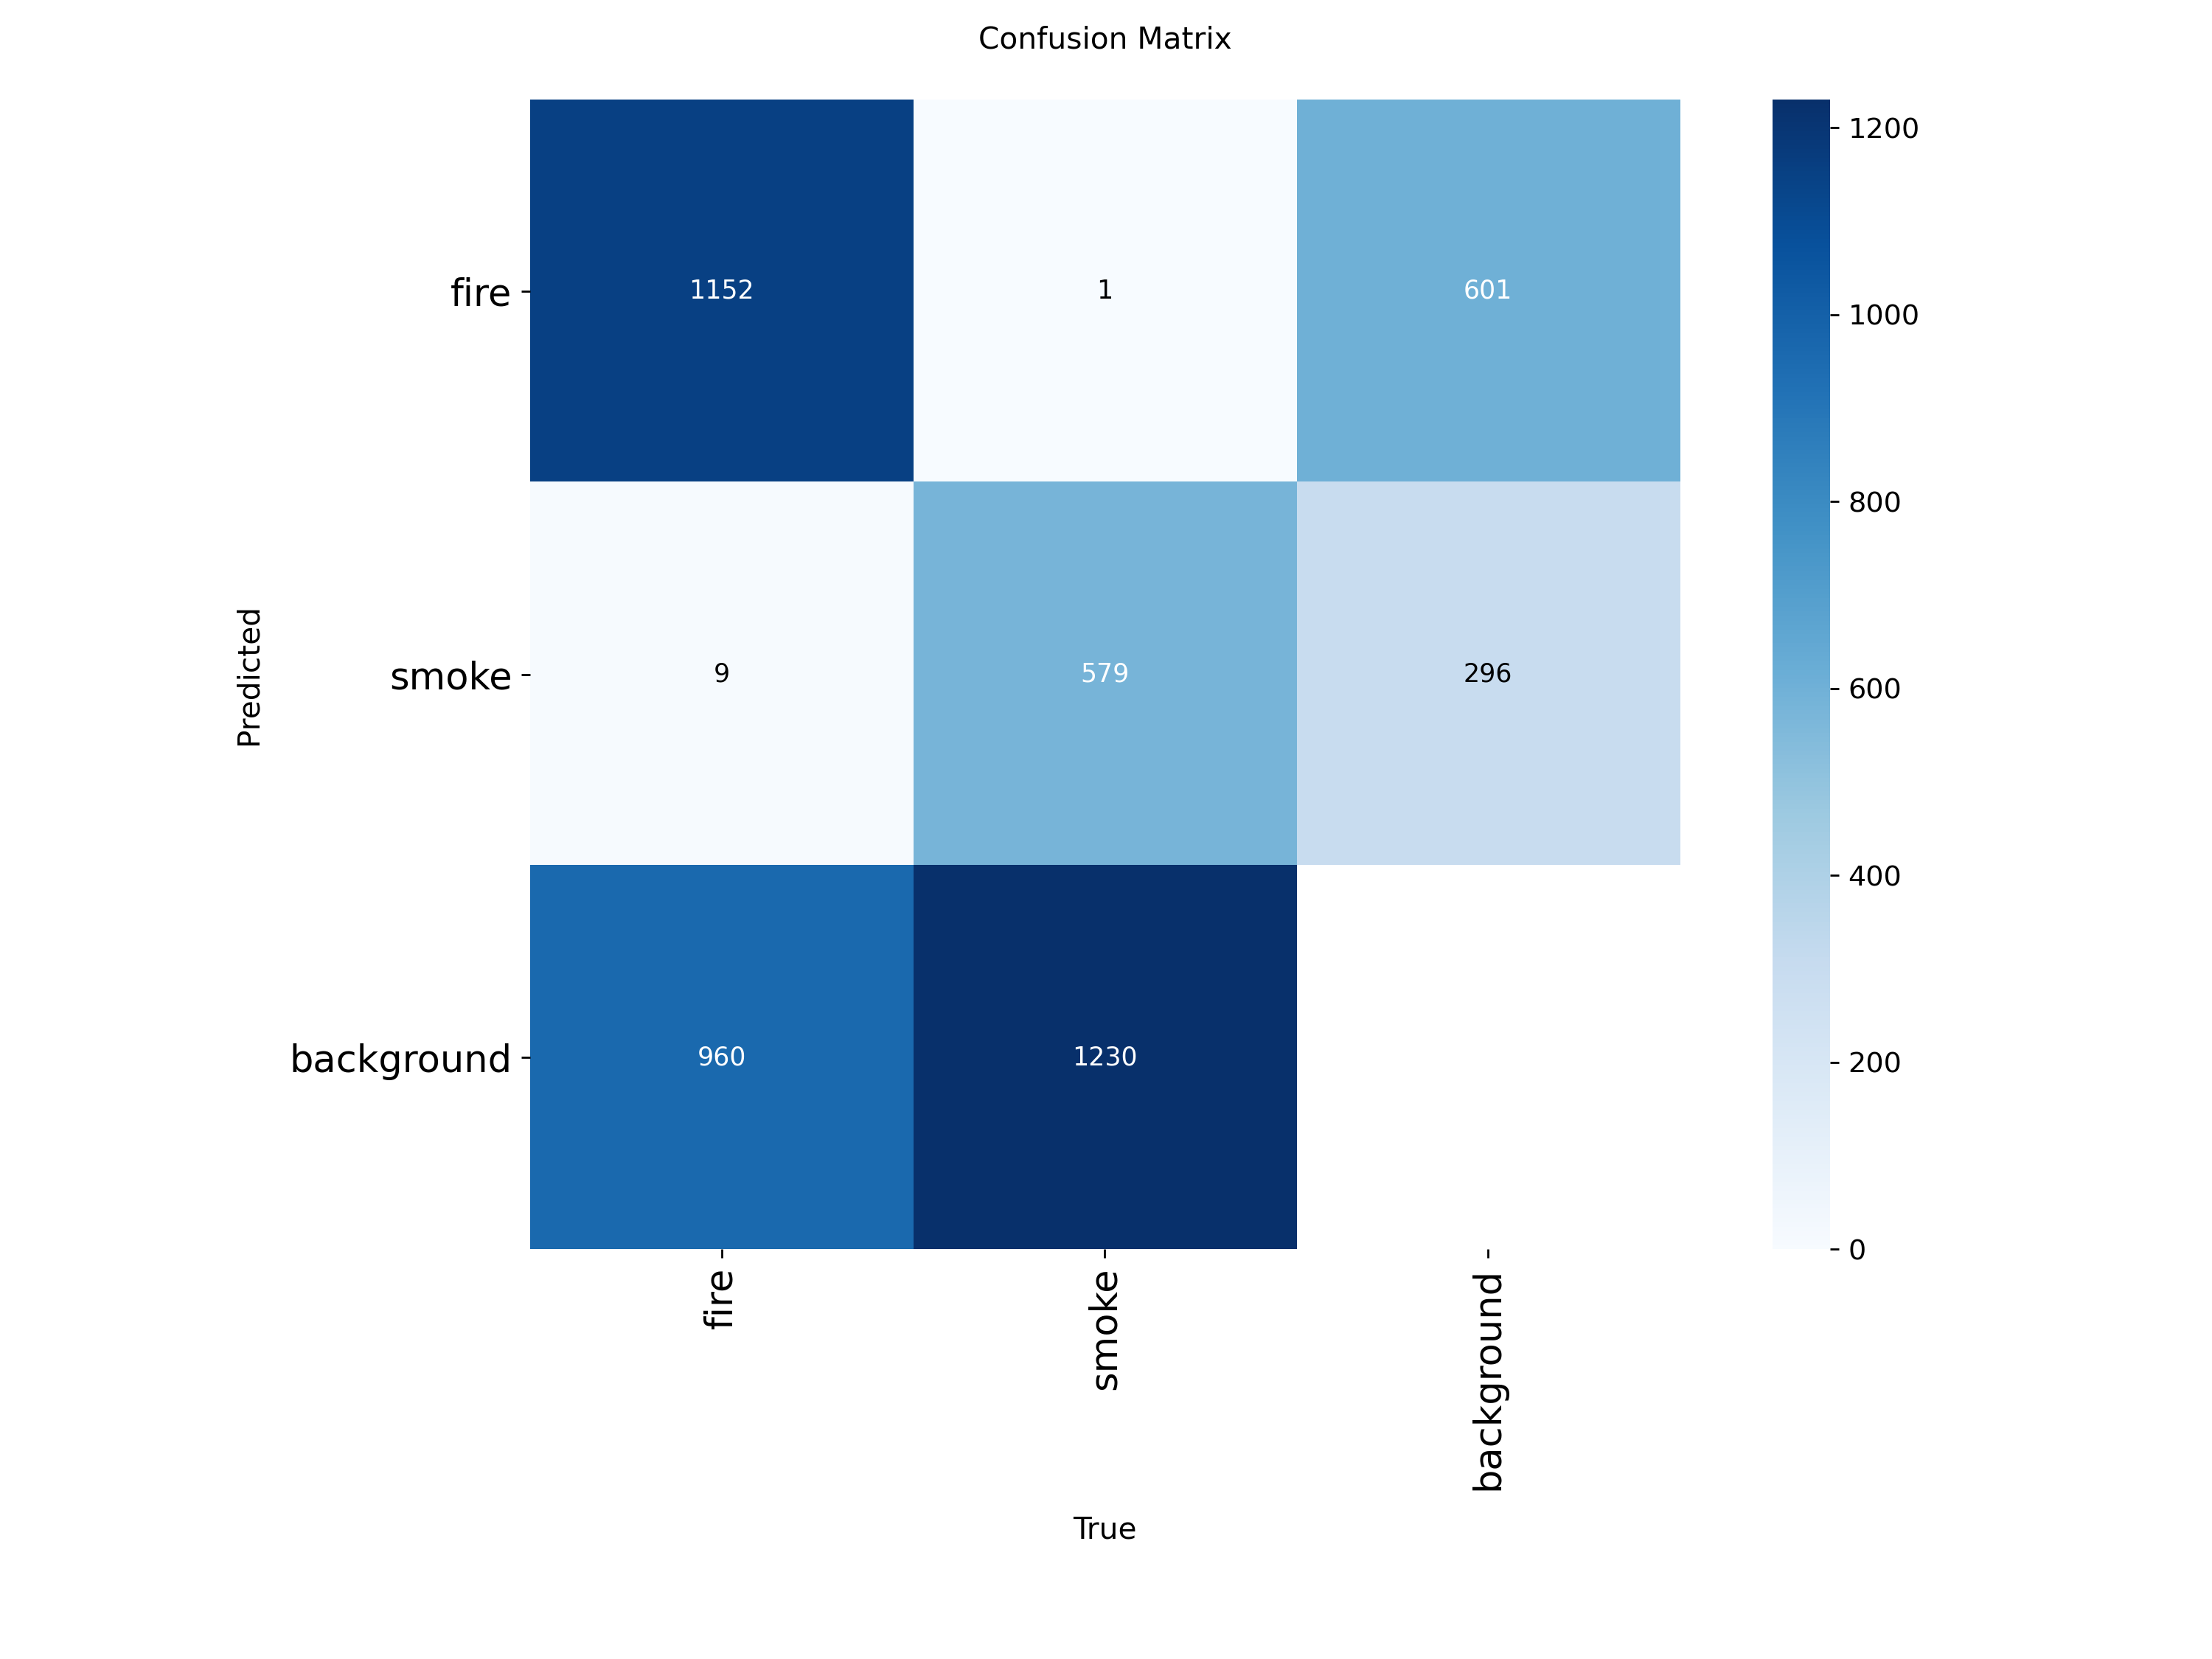


 confusion_matrix_normalized.png


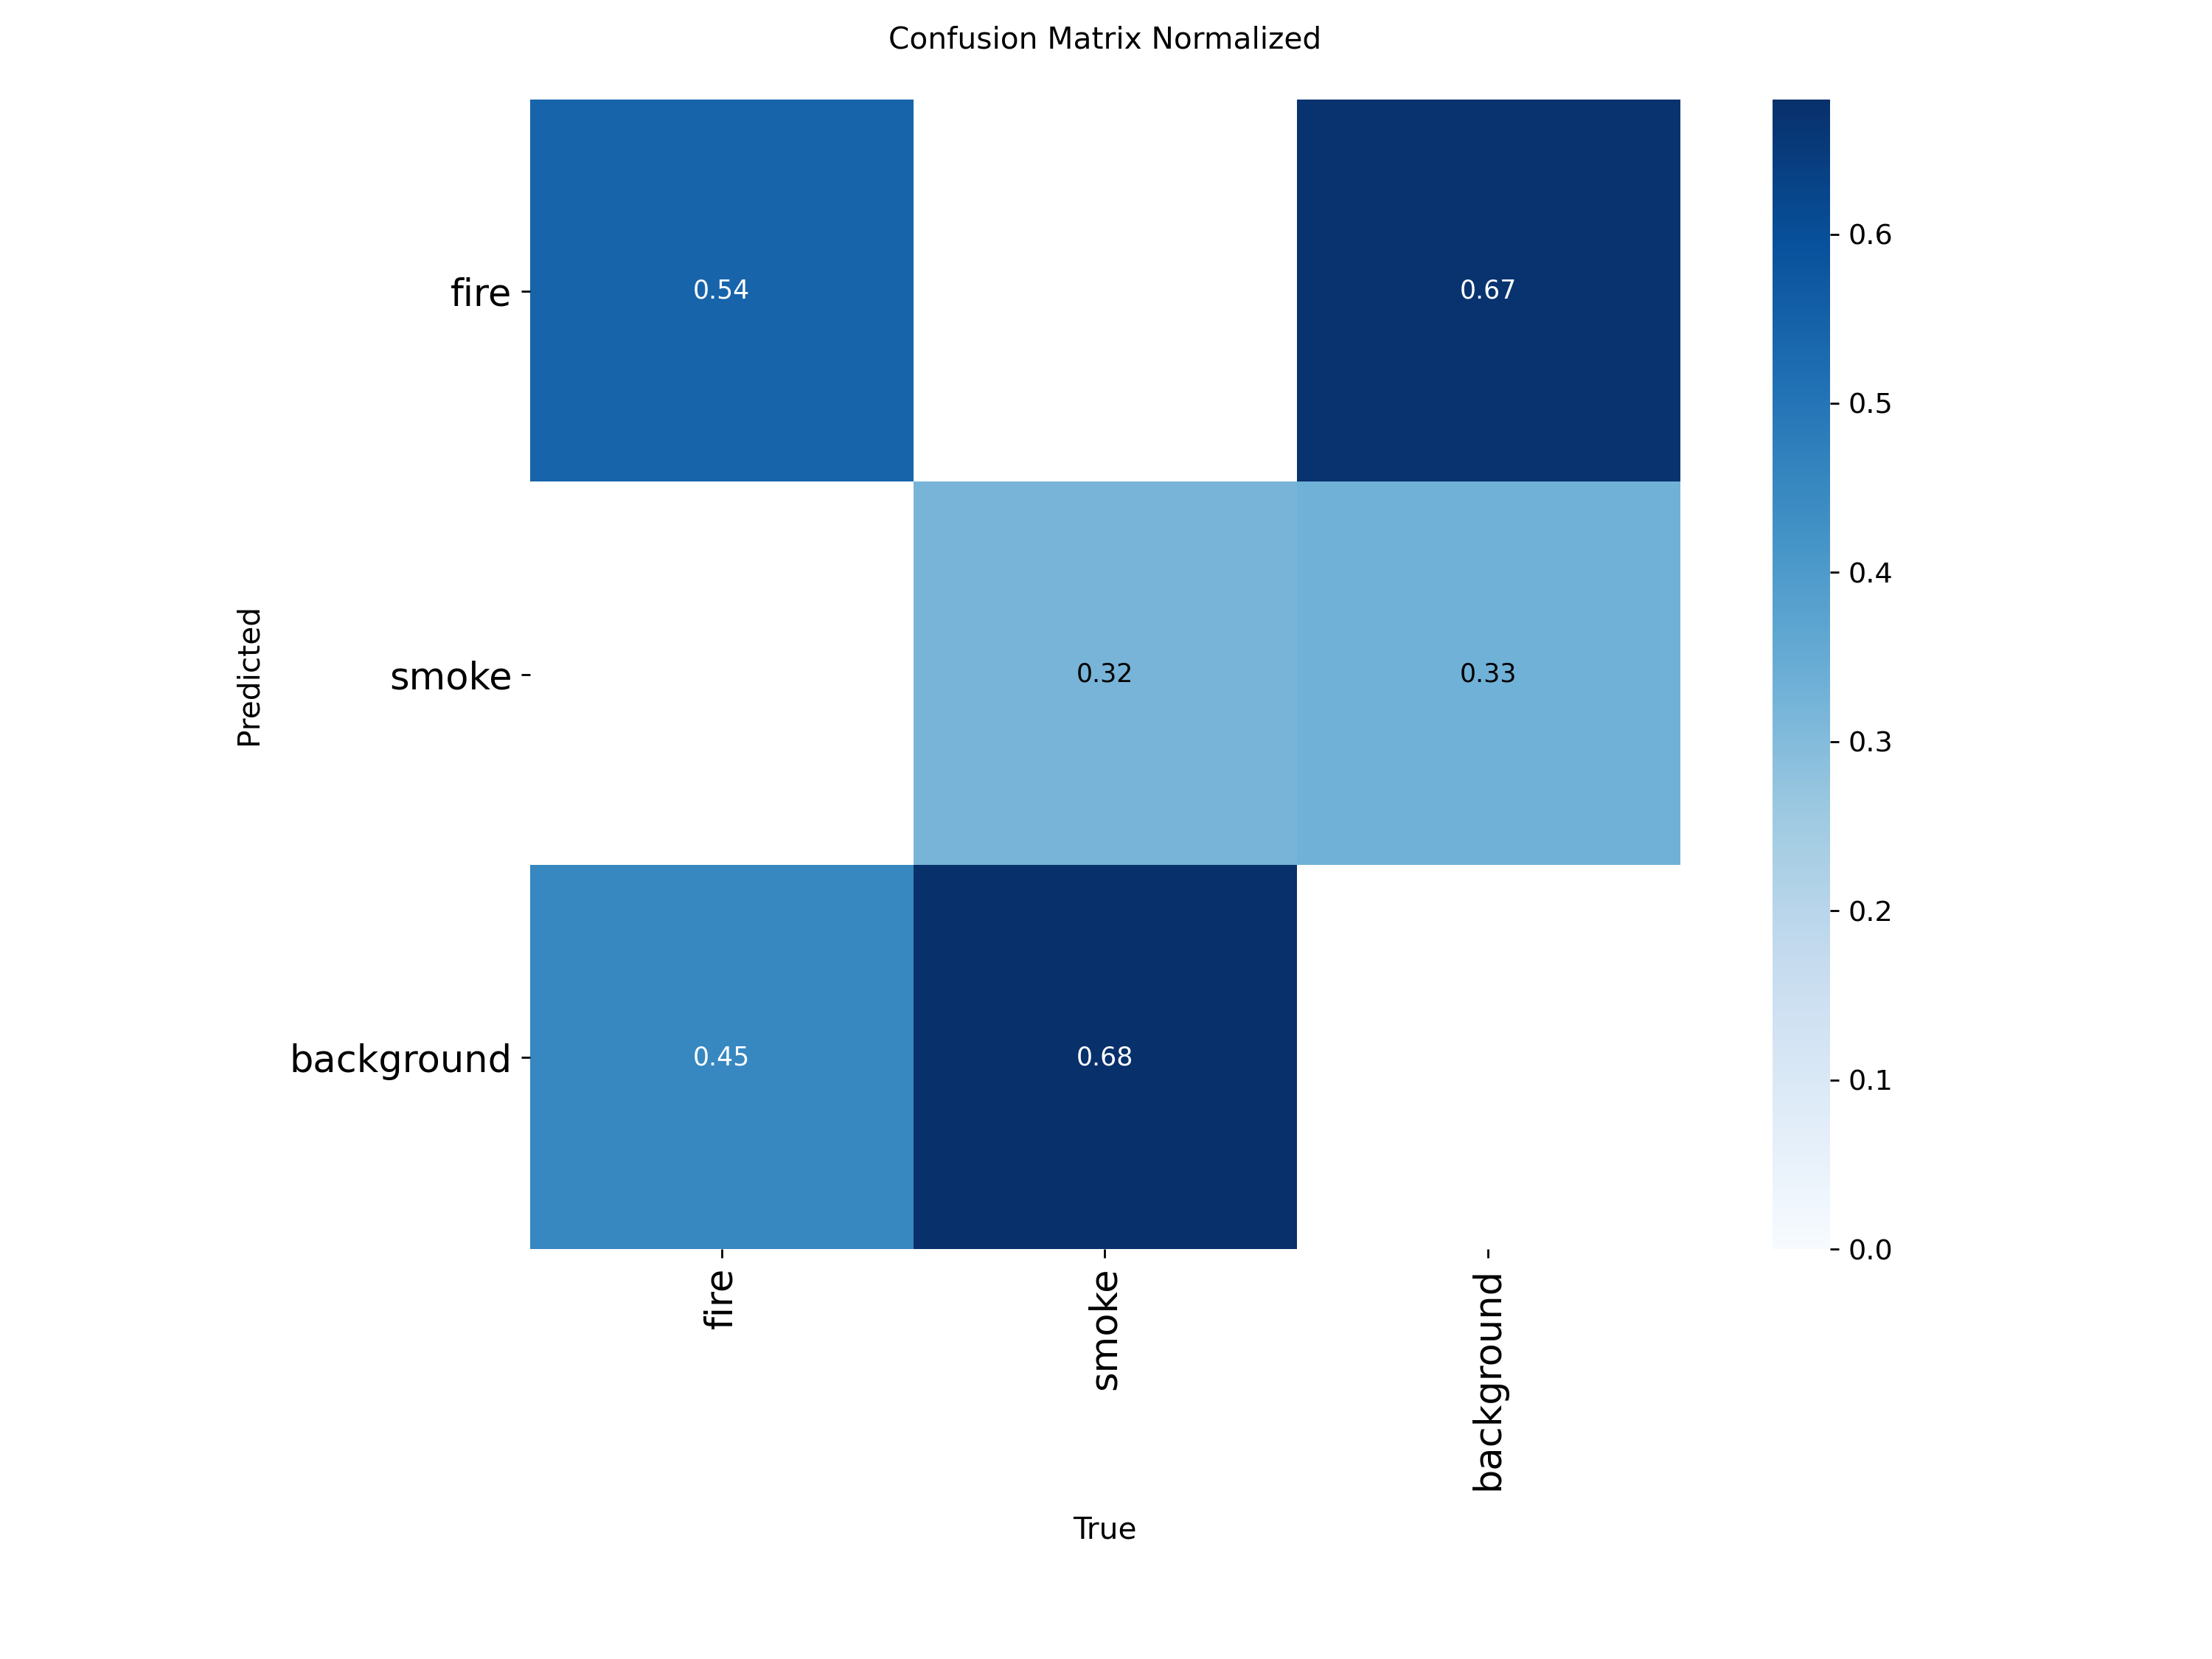

In [12]:
run_dirs = sorted(Path("/content/fire_smoke_project").glob("yolo_fire_smoke*"))

if run_dirs:
    run_dir = run_dirs[-1]
    print("Training run directory:", run_dir)

    possible_plots = [
        "results.png",
        "confusion_matrix.png",
        "confusion_matrix_normalized.png",
        "PR_curve.png",
        "F1_curve.png",
    ]

    for file_name in possible_plots:
        plot_path = run_dir / file_name
        if plot_path.exists():
            print("\n", file_name)
            display(Image.open(plot_path))
else:
    print("Training run directory was not found.")

In [13]:
TABLE_COLUMNS = ["Class", "Confidence", "x1", "y1", "x2", "y2"]

FIRE_KEYWORDS = ("fire", "flame")
SMOKE_KEYWORDS = ("smoke",)

def classify_risk(detected_labels):
    labels = [str(x).lower() for x in detected_labels]

    fire_found = any(any(k in label for k in FIRE_KEYWORDS) for label in labels)
    smoke_found = any(any(k in label for k in SMOKE_KEYWORDS) for label in labels)

    if fire_found:
        return "🚨 DANGER — FIRE DETECTED"
    if smoke_found:
        return "⚠️ WARNING — SMOKE DETECTED"
    return "✅ SAFE — NO FIRE/SMOKE DETECTED"


def detect_fire_smoke(image, confidence=0.25, iou=0.45):
    if image is None:
        empty = pd.DataFrame(columns=TABLE_COLUMNS)
        return None, "Please upload or capture an image.", "No image provided.", empty

    if isinstance(image, Image.Image):
        image = np.array(image.convert("RGB"))

    if image.ndim == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif image.shape[-1] == 4:
        image = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)

    # Gradio provides RGB; OpenCV/Ultralytics commonly consume BGR arrays.
    bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    results = fire_model.predict(
        source=bgr,
        conf=float(confidence),
        iou=float(iou),
        device=DEVICE,
        verbose=False,
    )

    result = results[0]

    annotated_bgr = result.plot()
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

    rows = []
    detected_labels = []

    if result.boxes is not None and len(result.boxes) > 0:
        boxes = result.boxes.xyxy.detach().cpu().numpy()
        confs = result.boxes.conf.detach().cpu().numpy()
        class_ids = result.boxes.cls.detach().cpu().numpy().astype(int)

        for box, conf, cls_id in zip(boxes, confs, class_ids):
            label = result.names[int(cls_id)]
            detected_labels.append(label)

            x1, y1, x2, y2 = box.tolist()
            rows.append({
                "Class": label,
                "Confidence": round(float(conf), 4),
                "x1": round(float(x1), 1),
                "y1": round(float(y1), 1),
                "x2": round(float(x2), 1),
                "y2": round(float(y2), 1),
            })

    status = classify_risk(detected_labels)

    if detected_labels:
        counts = Counter(detected_labels)
        count_text = ", ".join(f"{name}: {count}" for name, count in counts.most_common())
        summary = (
            f"Detected objects: {len(detected_labels)}\n"
            f"{count_text}\n"
            f"Confidence threshold: {float(confidence):.2f}"
        )
    else:
        summary = (
            "No fire/smoke objects were detected at the current threshold.\n"
            "For testing, you may lower the confidence threshold."
        )

    table = pd.DataFrame(rows, columns=TABLE_COLUMNS)

    return annotated_rgb, status, summary, table


print("✅ Fire/smoke inference function is ready.")

✅ Fire/smoke inference function is ready.


Saving Fire in Tress 1.jpg to Fire in Tress 1.jpg
🚨 DANGER — FIRE DETECTED
Detected objects: 1
fire: 1
Confidence threshold: 0.25


,Class,Confidence,x1,y1,x2,y2
0,fire,0.3117,39.3,22.3,77.0,85.8


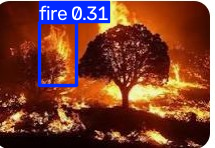

In [14]:
from google.colab import files

uploaded = files.upload()

image_files = [
    name for name in uploaded
    if name.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

if not image_files:
    print("No image uploaded. Skip this cell if you only want to use Gradio.")
else:
    test_path = image_files[0]
    test_rgb = np.array(Image.open(test_path).convert("RGB"))

    detected_img, status, summary, table = detect_fire_smoke(test_rgb)

    print(status)
    print(summary)
    display(table)
    display(Image.fromarray(detected_img))

Saving Fire IN Trees.jpg to Fire IN Trees.jpg
🚨 DANGER — FIRE DETECTED
Detected objects: 1
fire: 1
Confidence threshold: 0.25


,Class,Confidence,x1,y1,x2,y2
0,fire,0.5452,202.2,183.3,262.0,276.6


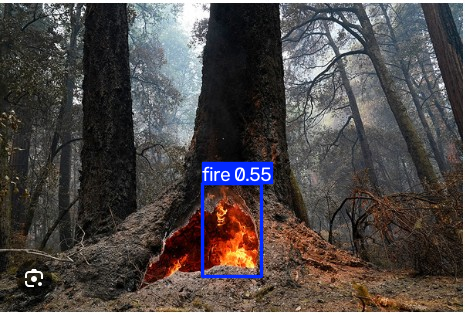

In [15]:
from google.colab import files

uploaded = files.upload()

image_files = [
    name for name in uploaded
    if name.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

if not image_files:
    print("No image uploaded. Skip this cell if you only want to use Gradio.")
else:
    test_path = image_files[0]
    test_rgb = np.array(Image.open(test_path).convert("RGB"))

    detected_img, status, summary, table = detect_fire_smoke(test_rgb)

    print(status)
    print(summary)
    display(table)
    display(Image.fromarray(detected_img))

In [16]:
CSS = """
.gradio-container {
    max-width: 1250px !important;
    margin: auto !important;
}
.project-title {
    text-align: center;
}
"""

with gr.Blocks(title="AI Fire & Smoke Detection", css=CSS) as demo:

    gr.Markdown(
        """
        <div class="project-title">
            <h1>🔥 AI Fire & Smoke Detection System</h1>
            <p>YOLO Computer Vision + Gradio Early-Warning Prototype</p>
        </div>
        """
    )

    gr.Markdown(
        """
        **Status interpretation:**
        ✅ SAFE = no model-detected fire/smoke
        ⚠️ WARNING = smoke detected
        🚨 DANGER = fire detected
        """
    )

    with gr.Row():

        with gr.Column():
            input_image = gr.Image(
                label="Camera / Input Image",
                type="numpy",
                sources=["upload", "webcam", "clipboard"],
            )

            confidence_slider = gr.Slider(
                0.05, 0.95,
                value=0.25,
                step=0.05,
                label="Confidence Threshold",
            )

            iou_slider = gr.Slider(
                0.10, 0.90,
                value=0.45,
                step=0.05,
                label="IoU Threshold",
            )

            with gr.Row():
                detect_btn = gr.Button("🔥 Analyze Scene", variant="primary")
                clear_btn = gr.ClearButton(
                    [input_image],
                    value="Clear"
                )

        with gr.Column():
            output_image = gr.Image(
                label="YOLO Detection Result",
                type="numpy",
            )

            risk_status = gr.Textbox(
                label="Early-Warning Status",
                lines=2,
                interactive=False,
            )

            detection_summary = gr.Textbox(
                label="Detection Summary",
                lines=4,
                interactive=False,
            )

    detection_table = gr.Dataframe(
        headers=TABLE_COLUMNS,
        datatype=["str", "number", "number", "number", "number", "number"],
        label="Detection Details",
        interactive=False,
    )

    detect_btn.click(
        fn=detect_fire_smoke,
        inputs=[input_image, confidence_slider, iou_slider],
        outputs=[output_image, risk_status, detection_summary, detection_table],
    )

    gr.Markdown(
        """
        ---
        ### Educational prototype
        Model predictions can be wrong. Never rely on this application as the sole method
        for detecting or responding to a real fire emergency.
        """
    )

print("✅ Gradio application created.")

/tmp/ipykernel_680/2143804336.py:11: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(title="AI Fire & Smoke Detection", css=CSS) as demo:


✅ Gradio application created.


In [17]:
demo.queue().launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://13e088f2cb3f59c208.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://13e088f2cb3f59c208.gradio.live


In [ ]:
CSS = """
.gradio-container {
    max-width: 1250px !important;
    margin: auto !important;
}
.project-title {
    text-align: center;
}
"""

with gr.Blocks(title="AI Fire & Smoke Detection", css=CSS) as demo:

    gr.Markdown(
        """
        <div class="project-title">
            <h1>🔥 AI Fire & Smoke Detection System</h1>
            <p>YOLO Computer Vision + Gradio Early-Warning Prototype</p>
        </div>
        """
    )

    gr.Markdown(
        """
        **Status interpretation:**
        ✅ SAFE = no model-detected fire/smoke
        ⚠️ WARNING = smoke detected
        🚨 DANGER = fire detected
        """
    )

    with gr.Row():

        with gr.Column():
            input_image = gr.Image(
                label="Camera / Input Image",
                type="numpy",
                sources=["upload", "webcam", "clipboard"],
            )

            confidence_slider = gr.Slider(
                0.05, 0.95,
                value=0.25,
                step=0.05,
                label="Confidence Threshold",
            )

            iou_slider = gr.Slider(
                0.10, 0.90,
                value=0.45,
                step=0.05,
                label="IoU Threshold",
            )

            with gr.Row():
                detect_btn = gr.Button("🔥 Analyze Scene", variant="primary")
                clear_btn = gr.ClearButton(
                    [input_image],
                    value="Clear"
                )

        with gr.Column():
            output_image = gr.Image(
                label="YOLO Detection Result",
                type="numpy",
            )

            risk_status = gr.Textbox(
                label="Early-Warning Status",
                lines=2,
                interactive=False,
            )

            detection_summary = gr.Textbox(
                label="Detection Summary",
                lines=4,
                interactive=False,
            )

    detection_table = gr.Dataframe(
        headers=TABLE_COLUMNS,
        datatype=["str", "number", "number", "number", "number", "number"],
        label="Detection Details",
        interactive=False,
    )

    detect_btn.click(
        fn=detect_fire_smoke,
        inputs=[input_image, confidence_slider, iou_slider],
        outputs=[output_image, risk_status, detection_summary, detection_table],
    )

    gr.Markdown(
        """
        ---
        ### Educational prototype
        Model predictions can be wrong. Never rely on this application as the sole method
        for detecting or responding to a real fire emergency.
        """
    )

print("✅ Gradio application created.")
demo.queue().launch(share=True, debug=True)

/tmp/ipykernel_680/2068107737.py:11: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(title="AI Fire & Smoke Detection", css=CSS) as demo:


✅ Gradio application created.
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://bb142c7e608fc518dc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
